# Explore Classification Results

Interactive notebook for inspecting and comparing classifier training runs.
Mirrors `05.plot_classifier_results.py` but designed for cell-by-cell exploration with immediate plot feedback.

**Sections**
1. Setup & configuration
2. Single-run analysis (summary, training curves, metric distributions, confusion matrix)
3. Comparative ROC curves across multiple runs

## 1. Setup

In [1]:
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import os, re, pickle, itertools
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('png')
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional
from collections import defaultdict
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

import sys
sys.path.insert(0, '/users/mbredber/p2_DCRECLASS/src')

from dcreclass.utils.calc_tools import (
    recalculate_metrics_with_correct_positive_class, round_to_1
)
from dcreclass.utils.plotting import (
    plot_training_history, plot_avg_std_confusion_matrix
)

plt.rcParams.update({'font.size': 9})

OUTPUT_DIR = '/users/mbredber/p2_DCRECLASS/outputs/scratch/figures/classifying/explore_classification_results_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print('Imports OK')
print('Output dir:', OUTPUT_DIR)

Imports OK
Output dir: /users/mbredber/p2_DCRECLASS/outputs/scratch/figures/classifying/explore_classification_results_outputs


In [2]:
import glob as _glob

@dataclass
class RunConfig:
    """All parameters that identify one training run.
    Defaults match script 04.
    """
    classifier:      str   = 'ImageCNN'
    version:         str   = 'RAW'          # e.g. RAW, T25kpc, T50kpc, T100kpc
    crop_mode:       str   = 'beam_crop'    # beam_crop | beam_crop_no_sub | fov_crop | cheat_crop | pixel_crop
    blur_method:     str   = 'circular'     # circular | circular_no_sub | cheat
    lr:              float = 5e-5
    reg:             float = 1e-1
    label_smoothing: float = 0.1
    percentile_lo:   int   = 30
    percentile_hi:   int   = 99
    folds:           List[int] = field(default_factory=lambda: [0])
    num_experiments: int   = 2
    galaxy_classes:  List[int] = field(default_factory=lambda: [50, 51])
    crop_size:       Tuple[int, int] = (512, 512)
    downsample_size: Tuple[int, int] = (128, 128)
    global_norm_mode: str  = 'percentile'
    adjust_positive_class: bool = True
    data_run_dir:    str   = '/users/mbredber/p2_DCRECLASS/outputs/scratch'
    # When multiple old-format files match, use this index to pick one (0 = first/alphabetically first)
    preferred_old_idx: int = 0

    @property
    def metrics_dir(self) -> str:
        sub = (f"{self.classifier}_{self.crop_mode}_{self.blur_method}_"
               f"{self.lr}_{self.reg}_{self.percentile_lo}_"
               f"{self.percentile_hi}_{self.label_smoothing}")
        return os.path.join(self.data_run_dir, 'data', 'metrics', sub)

    @property
    def old_metrics_dir(self) -> str:
        return os.path.join(self.data_run_dir, 'data', 'metrics', 'old')

    @property
    def dataset_sizes(self) -> Dict[int, List[int]]:
        if self.galaxy_classes == [50, 51]:
            return {fold: [3000] for fold in range(10)}
        if self.galaxy_classes == [52, 53]:
            return {fold: [2, 16, 168] for fold in range(10)}
        raise ValueError(f'No dataset_sizes defined for galaxy_classes={self.galaxy_classes}')

    def base_key(self, fold: int, subset_size: int) -> str:
        """Canonical key — mirrors script 04's _base()."""
        return (f"{self.classifier}_ver{self.version}_cm{self.crop_mode}"
                f"_lr{self.lr}_reg{self.reg}_ls{self.label_smoothing}"
                f"_lo{self.percentile_lo}_hi{self.percentile_hi}"
                f"_f{fold}_ss{round_to_1(subset_size)}")

    def pkl_path(self, fold: int, subset_size: int, experiment: int) -> str:
        return os.path.join(
            self.metrics_dir,
            f"{self.base_key(fold, subset_size)}_e{experiment}.pkl"
        )

    def find_old_pkls(self, fold: int, experiment: int) -> List[str]:
        """Glob old-format pkl files.
        Old data constraints:
        - blur_method must be 'circular' (cheat and tapering never ran)
        - non-RAW versions always used beam_crop (crop_mode overridden in glob)
        - version: BlurXkpc → RTXkpc (also try RAW+RTXkpc prefix variant)
        - suffix: RT files omit norm_mode token; RAW files include it
        """
        if self.blur_method != 'circular':
                return []

        # Old non-RAW runs only exist for beam_crop
        if self.version != 'RAW' and self.crop_mode != 'beam_crop':
            return []

        old_version         = re.sub(r'^Blur(\d+kpc)$', r'RT\1',     self.version)
        old_version_prefixed = re.sub(r'^Blur(\d+kpc)$', r'RAW+RT\1', self.version)

        # Non-RAW old files always used beam_crop regardless of self.crop_mode
        # RAW files used whatever crop_mode is set (already handled by existing logic)
        cs = f'cs{self.crop_size[0]}x{self.crop_size[1]}'
        ds = f'ds{self.downsample_size[0]}x{self.downsample_size[1]}'

        matches = []
        for ver in [old_version, old_version_prefixed]:
            base = (f"CNN_*"
                    f"_reg{self.reg}"
                    f"_lo{self.percentile_lo}"
                    f"_hi{self.percentile_hi}"
                    f"_{cs}_{ds}"
                    f"_ver{ver}"
                    f"_f{fold}"
                    f"_ss*"
                    f"_e{experiment}")
            for suffix in [f"_{self.global_norm_mode}_metrics_data.pkl", "_metrics_data.pkl"]:
                matches.extend(_glob.glob(os.path.join(self.old_metrics_dir, base + suffix)))

        return sorted(set(matches))

    def find_pkl(self, fold: int, subset_size: int, experiment: int) -> Optional[str]:
        """Return the path of the pkl to load.

        Priority:
        1. New-format path (metrics_dir / base_key_e{exp}.pkl) — if it exists.
        2. Old-format path (old_metrics_dir / *) — wildcard on lr, reg, subset_size.
           If multiple files match, the one at index `preferred_old_idx` is used and
           the others are printed so you can adjust preferred_old_idx to pick a different one.
        3. None — caller should treat as missing.
        """
        new_path = self.pkl_path(fold, subset_size, experiment)
        if os.path.exists(new_path):
            return new_path

        old_matches = self.find_old_pkls(fold, experiment)
        if not old_matches:
            return None

        idx = self.preferred_old_idx % len(old_matches)
        chosen = old_matches[idx]
        if len(old_matches) > 1:
            others = [p for i, p in enumerate(old_matches) if i != idx]
            print(f'  [old fallback fold={fold},exp={experiment}] '
                  f'Using (preferred_old_idx={self.preferred_old_idx}): {os.path.basename(chosen)}')
            print(f'  [old fallback fold={fold},exp={experiment}] '
                  f'Other matches — change preferred_old_idx to select:')
            for i, p in enumerate(old_matches):
                marker = ' ◀ selected' if i == idx else f'  (set preferred_old_idx={i})'
                print(f'    [{i}] {os.path.basename(p)}{marker}')
        else:
            print(f'  [old fallback fold={fold},exp={experiment}] {os.path.basename(chosen)}')
        return chosen

print('RunConfig defined')

RunConfig defined


In [3]:
import json as _json

@dataclass
class LegacyRunConfig:
    """Mimics RunConfig for use with plot_accuracy_bars/load_run.

    _draw_bars calls dataclasses.replace(cfg, version=..., blur_method=...)
    then load_run(cfg).  This class intercepts that call and reads from
    legacy_metrics.json instead of pkl files.
    """
    classifier:    str            # 'CNN' | 'DualCSN' | 'DualSSN'
    section:       str            # 'percentile' | 'stacking'
    legacy_path:   str = '/users/mbredber/p2_DCRECLASS/outputs/scratch/data/PSZ2/legacy_results/legacy_metrics.json'

    # Fields written by dataclasses.replace() inside _draw_bars:
    version:       str = 'RAW'
    blur_method:   str = 'circular'

    # Fields read by _draw_bars when building key k:
    lr:            float = 5e-5
    reg:           float = 0.1
    folds:         List[int] = field(default_factory=lambda: [0, 1])
    num_experiments: int = 1
    dataset_sizes: dict = field(default_factory=lambda: {0: [3000], 1: [3000]})

print('LegacyRunConfig defined')

LegacyRunConfig defined


In [4]:
_LEGACY_VERSION_MAP = {
    'beam_cropping': {
        'RAW':        'RAW',
        'Blur25kpc':  'RT25kpc',  'Blur50kpc':  'RT50kpc',  'Blur100kpc': 'RT100kpc',
        'T25kpc':     'T25kpc',   'T50kpc':     'T50kpc',   'T100kpc':    'T100kpc',
        'T50kpcSUB':  'T50kpcSUB', 'T100kpcSUB': 'T100kpcSUB',
    },
    'pixel_cropping': {
        'RAW':        'RAW',
    },
    'stacking': {
        'Blur25kpc':  'Raw+RT25kpc',  'Blur50kpc':  'Raw+RT50kpc',
        'Blur100kpc': 'Raw+RT100kpc', 'RAW':        'All',
    },
}

def _load_legacy_run(cfg: LegacyRunConfig) -> dict:
    with open(cfg.legacy_path) as f:
        legacy = _json.load(f)

    legacy_version = _LEGACY_VERSION_MAP[cfg.section].get(cfg.version)
    if legacy_version is None:
        print(f'  [legacy miss] {cfg.classifier}/{cfg.section}/{cfg.version} — not in map')
        return {'_cluster': {'errors': [], 'distances': [], 'std_devs': []},
                '_cfg': cfg, '_old_keys': set()}

    entry = legacy.get(cfg.section, {}).get(cfg.classifier, {}).get(legacy_version)
    if entry is None:
        print(f'  [legacy miss] {cfg.classifier}/{cfg.section}/{legacy_version}')
        return {'_cluster': {'errors': [], 'distances': [], 'std_devs': []},
                '_cfg': cfg, '_old_keys': set()}

    # Encode mean±std as two synthetic fold values so _draw_bars computes
    # the correct mean and std: std([µ−σ, µ+σ]) == σ (exact, ddof=0).
    tot = {}
    metric_map = {'accuracy': 'accuracy', 'precision': 'precision',
                  'recall': 'recall', 'f1': 'f1_score'}
    for fold, sign in [(0, -1.0), (1, +1.0)]:
        k = f'{cfg.dataset_sizes[fold][0]}_{fold}_0_{cfg.lr}_{cfg.reg}'
        for json_key, metric_key in metric_map.items():
            mean, std = entry[json_key]
            tot[f'{metric_key}_{k}'] = [mean + sign * std]
        tot[f'auc_{k}'] = [float('nan')]

    tot['_cluster'] = {'errors': [], 'distances': [], 'std_devs': []}
    tot['_cfg']      = cfg
    tot['_old_keys'] = set()
    print(f'Loaded 2 pkl files, failed/missing 0.')
    return tot

print('_load_legacy_run() defined')

_load_legacy_run() defined


In [5]:
def load_run(cfg, verbose: bool = True) -> dict:
    """Load all pkl files for a RunConfig.

    Tries the new-format path first; falls back to old-format files in the
    'old/' subdirectory (wildcard on lr, reg, subset_size).  When the old
    format is used the dict key for labels/probs may differ from the new
    base_key, so the loader falls back to inspecting available keys in the file.

    Returns a flat metrics dict plus special keys:
        '_cluster' : cluster-level diagnostics
        '_cfg'     : the RunConfig used
        '_old_keys': set of metric key suffixes (subset_fold_exp_lr_reg) whose
                     data came from old_metrics_dir.  Used by plot_accuracy_bars()
                     to draw those bars hollow.
    """
    if isinstance(cfg, LegacyRunConfig):
        return _load_legacy_run(cfg)
    tot = {}
    cluster = {'errors': [], 'distances': [], 'std_devs': []}
    loaded, failed = 0, 0

    # Keys (k = f'{subset}_{fold}_{exp}_{lr}_{reg}') loaded from old_metrics_dir
    old_keys: set = set()

    _cluster_map = {
        'cluster_error':    'errors',
        'cluster_distance': 'distances',
        'cluster_std_dev':  'std_devs',
    }

    # Auto-discover subset sizes from metrics_dir so dataset_sizes need not be exact
    import glob as _g_ss, re as _re_ss
    _disc_ss = set()
    for _f in _g_ss.glob(os.path.join(cfg.metrics_dir, '*.pkl')):
        _m = _re_ss.search(r'_ss(\d+(?:\.\d+)?)', os.path.basename(_f))
        if _m: _disc_ss.add(int(round_to_1(float(_m.group(1)))))
    _sizes = {f: sorted(set(cfg.dataset_sizes.get(f, [])) | _disc_ss)
              for f in cfg.folds}

    _loaded_paths: set = set()
    for experiment, fold in itertools.product(range(cfg.num_experiments), cfg.folds):
        for subset_size in _sizes[fold]:
            path = cfg.find_pkl(fold, subset_size, experiment)

            if path is None:
                if verbose:
                    print(f'  [miss] no file found for fold={fold}, subset={subset_size}, exp={experiment}')
                failed += 1
                continue
            if path in _loaded_paths:
                continue
            _loaded_paths.add(path)

            # Detect whether find_pkl() fell back to old_metrics_dir.
            # os.path.abspath normalises both sides before comparing.
            is_old = os.path.dirname(os.path.abspath(path)) == \
                     os.path.abspath(cfg.old_metrics_dir)

            try:
                with open(path, 'rb') as fh:
                    data = pickle.load(fh)
            except FileNotFoundError:
                if verbose:
                    print(f'  [miss] {os.path.basename(path)}')
                failed += 1
                continue
            except Exception as exc:
                if verbose:
                    print(f'  [err ] {os.path.basename(path)}: {exc}')
                failed += 1
                continue

            for src_key, dst_list in _cluster_map.items():
                val = data.get(src_key)
                if val is not None:
                    cluster[dst_list].append(val)

            # Resolve the dict key used to look up labels/probs.
            new_base = cfg.base_key(fold, subset_size)
            if new_base in data.get('all_true_labels', {}):
                base = new_base
            else:
                available = list(data.get('all_true_labels', {}).keys())
                if not available:
                    if verbose:
                        print(f'  [warn] {os.path.basename(path)}: all_true_labels is empty')
                    failed += 1
                    continue
                base = available[0]
                if verbose and path != cfg.pkl_path(fold, subset_size, experiment):
                    print(f'  [old key] using key {base!r}')

            y_true  = data['all_true_labels'].get(base, [])
            y_pred  = data['all_pred_labels'].get(base, [])
            y_probs = data['all_pred_probs'].get(base, [])

            if not y_true or not y_pred:
                failed += 1
                continue

            if cfg.adjust_positive_class:
                acc, prec, rec, f1 = recalculate_metrics_with_correct_positive_class(
                    y_true, y_pred, pos_label=0
                )
            else:
                m = data['metrics']
                acc  = m.get('accuracy',  [0.0])[0]
                prec = m.get('precision', [0.0])[0]
                rec  = m.get('recall',    [0.0])[0]
                f1   = m.get('f1_score',  [0.0])[0]

            auc_val = float('nan')
            if y_probs:
                try:
                    p = np.asarray(y_probs)
                    scores = p[:, 1] if p.ndim == 2 and p.shape[1] > 1 else p.ravel()
                    if np.unique(np.asarray(y_true)).size >= 2:
                        fpr_, tpr_, _ = roc_curve(y_true, scores)
                        auc_val = auc(fpr_, tpr_)
                except Exception:
                    pass

            k = f'{subset_size}_{fold}_{experiment}_{cfg.lr}_{cfg.reg}'

            # Register this key as old so the plotter can style it differently
            if is_old:
                old_keys.add(k)

            for metric, val in [('accuracy', acc), ('precision', prec),
                                 ('recall', rec), ('f1_score', f1), ('auc', auc_val)]:
                tot.setdefault(f'{metric}_{k}', []).append(val)

            for store_key, obj in [
                ('all_true_labels', data['all_true_labels']),
                ('all_pred_labels', data['all_pred_labels']),
                ('all_pred_probs',  data['all_pred_probs']),
                ('history',         data.get('history', {})),
                ('training_times',  data.get('training_times', {})),
            ]:
                tot.setdefault(f'{store_key}_{k}', []).append(obj)

            loaded += 1

    print(f'Loaded {loaded} pkl files, failed/missing {failed}.')
    tot['_cluster'] = cluster
    tot['_cfg']     = cfg
    tot['_old_keys'] = old_keys   # set of k-suffixes from old_metrics_dir
    return tot


print('load_run() defined')

load_run() defined


## 2. Single-run analysis

In [6]:
# ── Edit this cell to point at the run you want to inspect ───────────────────
cfg = RunConfig(
    classifier      = 'ImageCNN',
    version         = 'RAW',
    crop_mode       = 'beam_crop',
    blur_method     = 'circular',
    lr              = 5e-5,
    reg             = 1e-1,
    folds           = [0],
    num_experiments = 2,
)

print('metrics_dir :', cfg.metrics_dir)
print('example pkl :', cfg.pkl_path(0, 3000, 0))
print('exists      :', os.path.exists(cfg.pkl_path(0, 3000, 0)))

metrics_dir : /users/mbredber/p2_DCRECLASS/outputs/scratch/data/metrics/ImageCNN_beam_crop_circular_5e-05_0.1_30_99_0.1
example pkl : /users/mbredber/p2_DCRECLASS/outputs/scratch/data/metrics/ImageCNN_beam_crop_circular_5e-05_0.1_30_99_0.1/ImageCNN_verRAW_cmbeam_crop_lr5e-05_reg0.1_ls0.1_lo30_hi99_f0_ss3000_e0.pkl
exists      : True


In [7]:
metrics = load_run(cfg)

# Aggregate scalar metrics for the largest subset size across folds / experiments
metrics_last = defaultdict(list)
for fold in cfg.folds:
    subset = max(cfg.dataset_sizes[fold])
    for exp in range(cfg.num_experiments):
        k = f'{subset}_{fold}_{exp}_{cfg.lr}_{cfg.reg}'
        for metric in ['accuracy', 'precision', 'recall', 'f1_score', 'auc']:
            vals = metrics.get(f'{metric}_{k}', [])
            metrics_last[metric].extend(vals)

Loaded 2 pkl files, failed/missing 0.


In [8]:
print('=' * 55)
print('OVERALL PERFORMANCE SUMMARY')
print('=' * 55)
for metric in ['accuracy', 'precision', 'recall', 'f1_score', 'auc']:
    vals = np.array(metrics_last.get(metric, []), dtype=float)
    vals = vals[np.isfinite(vals)]
    label = 'AUC' if metric == 'auc' else metric.capitalize()
    if vals.size:
        print(f'  {label:12s}: {vals.mean():.4f} \u00b1 {vals.std():.4f}  (n={vals.size})')
    else:
        print(f'  {label:12s}: no data')
print('=' * 55)

OVERALL PERFORMANCE SUMMARY
  Accuracy    : 0.6318 ± 0.0000  (n=2)
  Precision   : 0.5654 ± 0.0000  (n=2)
  Recall      : 0.8578 ± 0.0000  (n=2)
  F1_score    : 0.6816 ± 0.0000  (n=2)
  AUC         : 0.7798 ± 0.0000  (n=2)


In [9]:
# Training history for fold 0, experiment 0
_fold, _exp = cfg.folds[0], 0
_subset = max(cfg.dataset_sizes[_fold])
_k = f'{_subset}_{_fold}_{_exp}_{cfg.lr}_{cfg.reg}'
_hist_list = metrics.get(f'history_{_k}', [])

if _hist_list and isinstance(_hist_list[0], dict):
    plot_training_history(_hist_list[0], cfg.base_key(_fold, _subset), _exp, save_dir=OUTPUT_DIR)
else:
    print('No history data found for fold 0 / experiment 0.')

Saved training history plot to /users/mbredber/p2_DCRECLASS/outputs/scratch/figures/classifying/explore_classification_results_outputs/ImageCNN_verRAW_cmbeam_crop_lr5e-05_reg0.1_ls0.1_lo30_hi99_f0_ss3000_exp0_training_curves.pdf


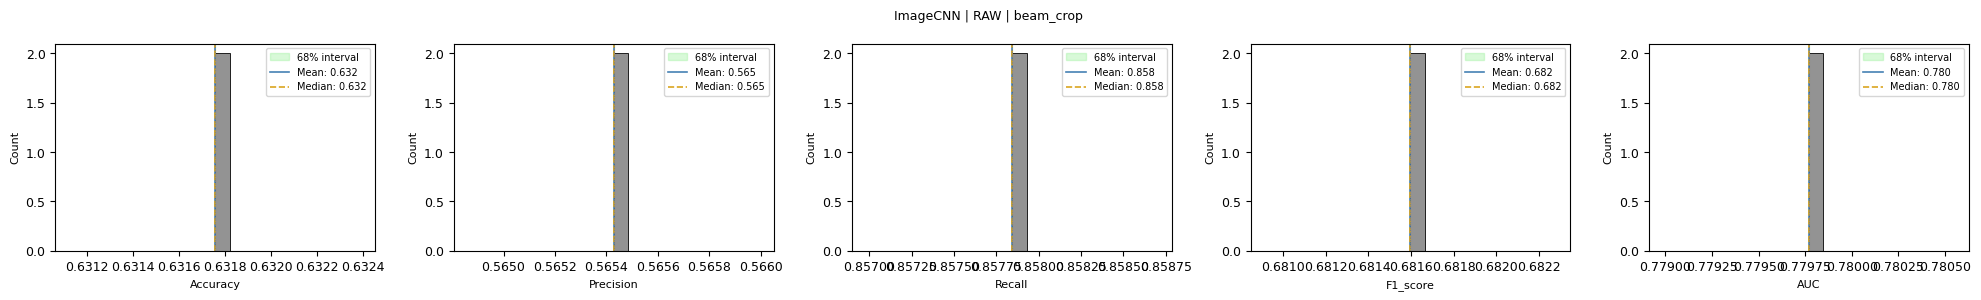

Saved: /users/mbredber/p2_DCRECLASS/outputs/scratch/figures/classifying/explore_classification_results_outputs/metric_distributions_ImageCNN_RAW_beam_crop.pdf


In [10]:
# Metric distributions across all folds & experiments
METRICS_TO_PLOT = ['accuracy', 'precision', 'recall', 'f1_score', 'auc']
fig, axes = plt.subplots(1, len(METRICS_TO_PLOT),
                         figsize=(4.0 * len(METRICS_TO_PLOT), 3.0))

for ax, metric in zip(axes, METRICS_TO_PLOT):
    vals = np.array(metrics_last.get(metric, []), dtype=float)
    vals = vals[np.isfinite(vals)]
    label = 'AUC' if metric == 'auc' else metric.capitalize()

    if vals.size == 0:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(label)
        continue

    p16, p50, p84 = np.percentile(vals, [16, 50, 84])
    mean = vals.mean()

    vmin, vmax = float(vals.min()), float(vals.max())
    if vmin == vmax:
        eps = max(1e-6, abs(vmin) * 1e-3)
        vmin, vmax = vmin - eps, vmax + eps
    edges = np.linspace(vmin, vmax, 21)

    ax.hist(vals, bins=edges, histtype='stepfilled',
            color='gray', edgecolor='black', linewidth=0.7, alpha=0.85)
    ax.axvspan(p16, p84, color='lightgreen', alpha=0.35, zorder=0, label='68% interval')
    ax.axvline(mean, color='steelblue', linewidth=1.2, label=f'Mean: {mean:.3f}')
    ax.axvline(p50, color='goldenrod', linewidth=1.2, linestyle='--', label=f'Median: {p50:.3f}')
    ax.axvline(p16, color='grey', linewidth=0.7, linestyle=':')
    ax.axvline(p84, color='grey', linewidth=0.7, linestyle=':')
    ax.set_xlabel(label, fontsize=8)
    ax.set_ylabel('Count', fontsize=8)
    ax.legend(fontsize=7, framealpha=0.8)

fig.suptitle(f"{cfg.classifier} | {cfg.version} | {cfg.crop_mode}", fontsize=9)
plt.tight_layout()
_fname = os.path.join(OUTPUT_DIR, f'metric_distributions_{cfg.classifier}_{cfg.version}_{cfg.crop_mode}.pdf')
plt.savefig(_fname, bbox_inches='tight')
plt.show()
plt.close()
print('Saved:', _fname)

In [11]:
# Average confusion matrix (saves to /tmp and displays inline)
_save_dir = '/tmp/dcreclass_nb'
os.makedirs(_save_dir, exist_ok=True)

_largest_sz = max(sz for sizes in cfg.dataset_sizes.values() for sz in sizes)

plot_avg_std_confusion_matrix(
    metrics, dict(metrics_last),
    cfg.galaxy_classes, cfg.classifier,
    cfg.version, _largest_sz,
    [cfg.lr], [cfg.reg],
    cfg.folds, cfg.dataset_sizes,
    cfg.crop_size, cfg.downsample_size,
    cfg.percentile_lo, cfg.percentile_hi,
    num_experiments=cfg.num_experiments,
    save_dir=_save_dir,
)

# Display the saved figure inline
from IPython.display import Image, display
import glob
for _fp in sorted(glob.glob(os.path.join(_save_dir, '*.pdf'))):
    print('Saved:', _fp)

## 3. Comparative ROC curves

Use `plot_comparative_roc` to overlay average ROC curves from different runs on one plot.
Each run is specified as a `(label, RunConfig)` pair. Vary any field between runs.

In [12]:
def plot_comparative_roc(
    run_configs: List[Tuple[str, RunConfig]],
    subset_size: Optional[int] = None,
    ax: Optional[plt.Axes] = None,
    figsize: Tuple[float, float] = (5.5, 5.5),
    colours: Optional[List[str]] = None,
    title: Optional[str] = None,  # reserved for future use, currently has no effect
) -> plt.Figure:
    DEFAULT_COLOURS = ['steelblue', 'goldenrod', 'tomato',
                       'mediumpurple', 'darkcyan', 'coral', 'olivedrab']
    if colours is None:
        colours = DEFAULT_COLOURS

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.get_figure()

    fpr_grid = np.linspace(0, 1, 1000)

    for cfg_idx, (label, cfg) in enumerate(run_configs):
        colour = colours[cfg_idx % len(colours)]

        # Rename crop type labels for display
        display_label = (label
                         .replace('beam_crop', 'Beam crop')
                         .replace('fov_crop',  'FoV crop'))

        # Determine subset size to use
        _all_sizes = sorted({sz for fs in cfg.dataset_sizes.values() for sz in fs})
        _ss = subset_size if subset_size is not None else _all_sizes[-1]

        print(f'\n[{label}] Subset size used: {_ss}  (all available: {_all_sizes})')

        min_class   = min(cfg.galaxy_classes)
        n_classes   = len(cfg.galaxy_classes)
        adj_classes = list(range(n_classes))
        roc_values  = {c: [] for c in adj_classes}

        # Collect per-fold accuracies for printing
        fold_accuracies = []

        n_loaded  = 0
        n_skipped = 0
        
        for experiment, fold in itertools.product(range(cfg.num_experiments), cfg.folds):
            if _ss not in cfg.dataset_sizes.get(fold, []):
                print(f'  [fold={fold}, exp={experiment}] SKIP — size {_ss} not in dataset_sizes for this fold')
                n_skipped += 1
                continue

            path = cfg.pkl_path(fold, _ss, experiment)
            print(f'  [fold={fold}, exp={experiment}] Trying: {path}')

            try:
                with open(path, 'rb') as fh:
                    data = pickle.load(fh)
                print(f'    -> Loaded OK')
            except FileNotFoundError:
                print(f'    -> NOT FOUND')
                n_skipped += 1
                continue

        #for experiment, fold in itertools.product(range(cfg.num_experiments), cfg.folds):
        #    if _ss not in cfg.dataset_sizes.get(fold, []):
        #        print(f'  [fold={fold}, exp={experiment}] SKIP — size {_ss} not in dataset_sizes for this fold')
        #        n_skipped += 1
        #        continue
#
        #    import io as _io, contextlib as _contextlib
        #    _buf = _io.StringIO()
        #    with _contextlib.redirect_stdout(_buf):
        #        path = cfg.find_pkl(fold, _ss, experiment)
        #    if path is None:
        #        print(f'  [fold={fold}, exp={experiment}] -> NOT FOUND (no new or old file)')
        #        n_skipped += 1
        #        continue
        #    print(f'  [fold={fold}, exp={experiment}] Trying: {path}')
        #    try:
        #        with open(path, 'rb') as fh:
        #            data = pickle.load(fh)
        #        print(f'    -> Loaded OK')
        #    except Exception as exc:
        #        print(f'    -> ERROR: {exc}')
        #        n_skipped += 1
        #        continue

            base = cfg.base_key(fold, _ss)
            print(f'    -> base_key: {base!r}')

            y_true  = data['all_true_labels'].get(base)
            y_probs = data['all_pred_probs'].get(base)

            if y_true is None or y_probs is None or len(y_true) == 0:
                print(f'    -> WARN: y_true or y_probs missing/empty for key {base!r}')
                print(f'       Available keys in all_true_labels: {list(data["all_true_labels"].keys())}')
                continue

            y_true  = np.asarray(y_true)
            y_probs = np.asarray(y_probs)

            # Remap class tags to 0-based indices if needed
            if y_true.max() > n_classes - 1:
                tag_to_idx = {tag: i for i, tag in enumerate(sorted(cfg.galaxy_classes))}
                y_true = np.vectorize(tag_to_idx.get)(y_true)

            if np.unique(y_true).size < 2:
                print(f'    -> WARN: only one class present in y_true, skipping fold')
                continue

            # Compute and store accuracy: fraction of correctly predicted samples
            y_pred = np.argmax(y_probs, axis=1) if y_probs.ndim == 2 else (y_probs.ravel() > 0.5).astype(int)
            fold_acc = np.mean(y_pred == y_true)
            fold_accuracies.append(fold_acc)
            print(f'    -> Accuracy: {fold_acc:.4f}')

            if n_classes == 2:
                scores = (y_probs[:, 1] if y_probs.ndim == 2 and y_probs.shape[1] > 1
                          else y_probs.ravel())
                fpr_, tpr_, _ = roc_curve(y_true, scores, pos_label=1)
                roc_values[1].append(np.interp(fpr_grid, fpr_, tpr_))
            else:
                y_bin = label_binarize(y_true, classes=adj_classes)
                for i, cls in enumerate(adj_classes):
                    fpr_, tpr_, _ = roc_curve(y_bin[:, i], y_probs[:, i])
                    roc_values[cls].append(np.interp(fpr_grid, fpr_, tpr_))

            n_loaded += 1

        print(f'\n[{label}] Summary: {n_loaded} folds loaded, {n_skipped} skipped/missing')

        # Print accuracy summary across all folds
        if fold_accuracies:
            acc_arr = np.array(fold_accuracies)
            mean_acc = np.mean(acc_arr)
            p16_acc, p84_acc = np.percentile(acc_arr, [16, 84])
            print(f'[{label}] Accuracy: mean={mean_acc:.4f}, '
                  f'16th={p16_acc:.4f}, 84th={p84_acc:.4f}  (n={len(acc_arr)} folds)')

        if n_loaded == 0:
            print(f'  [{label}] No data found — check metrics_dir and config.')
            continue

        plot_classes = [1] if n_classes == 2 else adj_classes
        for cls in plot_classes:
            if not roc_values[cls]:
                continue
            tpr_arr  = np.array(roc_values[cls])
            mean_tpr = np.mean(tpr_arr, axis=0)
            p16_tpr, p84_tpr = np.percentile(tpr_arr, [16, 84], axis=0)

            mean_auc  = auc(fpr_grid, mean_tpr)
            auc_arr   = [auc(fpr_grid, tpr_arr[i]) for i in range(len(tpr_arr))]
            p16_auc, p84_auc = np.percentile(auc_arr, [16, 84])

            # Use the renamed display label in the legend
            legend = (f'{display_label}  '
                      f'(AUC={mean_auc:.3f}, [{p16_auc:.3f}\u2013{p84_auc:.3f}], n={len(tpr_arr)})')

            ax.plot(fpr_grid, mean_tpr, color=colour, linewidth=1.4, label=legend)

            # Shaded band for 16th–84th percentile range; dotted boundary lines removed
            ax.fill_between(fpr_grid,
                            np.clip(p16_tpr, 0, 1),
                            np.clip(p84_tpr, 0, 1),
                            color=colour, alpha=0.15)

    ax.plot([0, 1], [0, 1], color='black', linewidth=0.8, linestyle='--',
            label='Random classifier')
    ax.set_xlim(0, 1);  ax.set_ylim(0, 1.05)
    ax.set_xlabel('False Positive Rate', fontsize=9)
    ax.set_ylabel('True Positive Rate',  fontsize=9)
    ax.legend(loc='lower right', fontsize=8, framealpha=0.9)
    # Title intentionally omitted
    fig.tight_layout()
    return fig

### Example: compare crop modes on RAW data

Edit the list below to vary any `RunConfig` field between runs.

In [13]:
def make_runs(
    crop_modes:  List[str],
    classifiers: List[str],
    version:     str = 'RAW',
    folds:       List[int] = list(range(10)),
    num_experiments: int = 3,
) -> List[Tuple[str, RunConfig]]:
    """Build runs_to_compare from all combinations of crop_mode × classifier."""
    _display = {'ImageCNN': 'CNN'}
    return [
        (f'{crop}_{_display.get(clf, clf)}', RunConfig(
            crop_mode       = crop,
            classifier      = clf,
            version         = version,
            folds           = folds,
            num_experiments = num_experiments,
        ))
        for crop, clf in itertools.product(crop_modes, classifiers)
    ]


[beam_crop_CNN] Subset size used: 3000  (all available: [3000])
  [fold=0, exp=0] Trying: /users/mbredber/p2_DCRECLASS/outputs/scratch/data/metrics/ImageCNN_beam_crop_circular_5e-05_0.1_30_99_0.1/ImageCNN_verRAW_cmbeam_crop_lr5e-05_reg0.1_ls0.1_lo30_hi99_f0_ss3000_e0.pkl
    -> Loaded OK
    -> base_key: 'ImageCNN_verRAW_cmbeam_crop_lr5e-05_reg0.1_ls0.1_lo30_hi99_f0_ss3000'
    -> Accuracy: 0.6318
  [fold=1, exp=0] Trying: /users/mbredber/p2_DCRECLASS/outputs/scratch/data/metrics/ImageCNN_beam_crop_circular_5e-05_0.1_30_99_0.1/ImageCNN_verRAW_cmbeam_crop_lr5e-05_reg0.1_ls0.1_lo30_hi99_f1_ss3000_e0.pkl
    -> Loaded OK
    -> base_key: 'ImageCNN_verRAW_cmbeam_crop_lr5e-05_reg0.1_ls0.1_lo30_hi99_f1_ss3000'
    -> Accuracy: 0.7230
  [fold=2, exp=0] Trying: /users/mbredber/p2_DCRECLASS/outputs/scratch/data/metrics/ImageCNN_beam_crop_circular_5e-05_0.1_30_99_0.1/ImageCNN_verRAW_cmbeam_crop_lr5e-05_reg0.1_ls0.1_lo30_hi99_f2_ss3000_e0.pkl
    -> Loaded OK
    -> base_key: 'ImageCNN_verRAW_cm

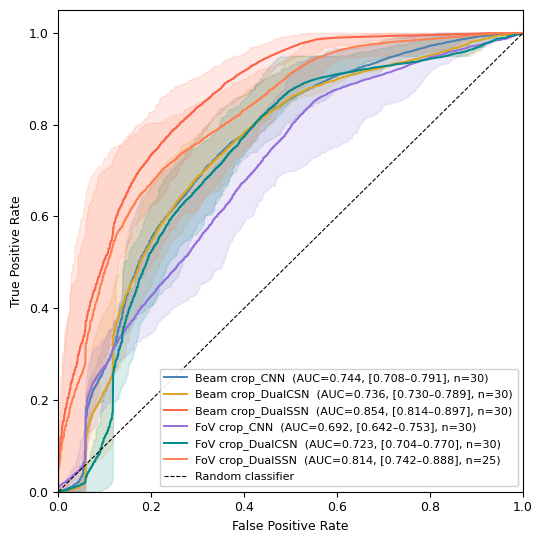

Saved: /users/mbredber/p2_DCRECLASS/outputs/scratch/figures/classifying/explore_classification_results_outputs/roc_comparison.pdf


In [ ]:
# ── Define runs to compare ────────────────────────────────────────────────────
# Each entry: (label, RunConfig)  — only vary the fields you want to compare;
# everything else defaults to the script-04 defaults.

runs_to_compare = make_runs(
    crop_modes  = ['beam_crop', 'fov_crop'],
    classifiers = ['ImageCNN', 'DualCSN', 'DualSSN'],
)

# T25kpc beam_crop DualSSN
# Raw....

# ── Plot ──────────────────────────────────────────────────────────────────────
fig = plot_comparative_roc(
    runs_to_compare,
    title='ROC comparison — RAW data, crop mode varies',
)
_fname = os.path.join(OUTPUT_DIR, 'roc_comparison.pdf')
fig.savefig(_fname, bbox_inches='tight')
plt.show()
plt.close()
print('Saved:', _fname)

## 4. Grouped accuracy bar chart

`plot_accuracy_bars` produces a grouped bar chart where:
- **x-axis** — one group per value of `x_vary` (e.g. different classifiers or data versions)
- **bar colours** — one bar per value of `color_vary` (e.g. crop mode or blur method)
- **bar height / error bar** — mean ± std of `metric` aggregated across all folds and experiments

Both axes are fully configurable; only vary the two dimensions you care about and hold everything else fixed in `base_cfg`.

In [15]:
import dataclasses
import io
import re
import contextlib
from typing import Optional, List, Tuple
from matplotlib.patches import Patch


# ── Version-string helpers ─────────────────────────────────────────────────────

def _scale_to_version(scale: int, kind: str) -> str:
    if scale == 0:
        return 'RAW'
    if kind == 'blur':
        return f'Blur{scale}kpc'
    if kind == 'tap':
        return f'T{scale}kpc'
    if kind == 'tap_sub':
        return f'T{scale}kpcSUB'
    raise ValueError(f"Unknown kind '{kind}'. Use 'blur', 'tap', or 'tap_sub'.")


def _scale_label(scale: int) -> str:
    NARROW = '\u202f'
    if scale == 0:
        return 'Reference'
    return f'{scale}{NARROW}kpc'


def _load_vals_from_cfg(cfg, metric, run=None):
    """Load metric values from a run dict, split by tier (latest / old / legacy).

    Parameters
    ----------
    cfg     : RunConfig or LegacyRunConfig
    metric  : metric name string
    run     : pre-loaded run dict (pass if already loaded to avoid double load)

    Returns
    -------
    vals_by_tier : dict with keys 'latest', 'old', 'legacy'
    n_loaded, n_failed : ints parsed from load_run stdout
    """
    if run is None:
        buf = io.StringIO()
        with contextlib.redirect_stdout(buf):
            run = load_run(cfg, verbose=False)
        captured = buf.getvalue()
    else:
        captured = ''

    n_loaded, n_failed = 0, 0
    for line in captured.splitlines():
        m = re.search(r'Loaded\s+(\d+)\s+pkl', line)
        if m:
            n_loaded += int(m.group(1))
        m = re.search(r'failed/missing\s+(\d+)', line)
        if m:
            n_failed += int(m.group(1))

    is_legacy    = isinstance(cfg, LegacyRunConfig)
    old_keys     = run.get('_old_keys', set())
    vals_by_tier = {'latest': [], 'old': [], 'legacy': []}

    for fold in cfg.folds:
        for exp in range(cfg.num_experiments):
            # Collect from all subset sizes present in run dict (ignore dataset_sizes)
            _suffix = f'_{fold}_{exp}_{cfg.lr}_{cfg.reg}'
            for _rk, _rv in run.items():
                if not _rk.startswith(f'{metric}_') or not _rk.endswith(_suffix):
                    continue
                new_vals = [v for v in _rv if np.isfinite(v)]
                if not new_vals:
                    continue
                k = _rk[len(f'{metric}_'):]
                if is_legacy:
                    vals_by_tier['legacy'].extend(new_vals)
                elif k in old_keys:
                    vals_by_tier['old'].extend(new_vals)
                else:
                    vals_by_tier['latest'].extend(new_vals)

    return vals_by_tier, n_loaded, n_failed


# ── Single-axes drawing helper ─────────────────────────────────────────────────

def _draw_bars(
    ax,
    base_cfg,
    fallback_cfg,
    scales:         List[int],
    metric:         str,
    tracks:         list,
    _blur_methods:  Optional[list],
    _ov_vals:       list,
    _ov_labs:       list,
    overlay_vary:   Optional[str],
    COLOURS:        list,
    show_legend:    bool,
    show_xticks:    bool,
    show_radiounet_ref: bool,
    radiounet_value: float,
    metric_ylabel:  str,
    distinguish_result_versions: bool,
    result_version_priority: List[str],
    legacy_overlay_value: Optional[str],
    show_n_files: bool = False,
) -> list:
    """Draw all bars for one axes panel.  Returns the load_log for printing."""

    n_tracks    = len(tracks)
    n_x         = len(scales)
    group_width = 0.78
    sub_width   = group_width / n_tracks
    bar_width   = sub_width * 0.84
    x_pos       = np.arange(n_x, dtype=float)
    x_labels    = [_scale_label(s) for s in scales]

    load_log: list = []
    alpha_bar = 0.70 if len(_ov_vals) > 1 else 0.85

    is_legacy_base = isinstance(base_cfg, LegacyRunConfig)
    has_fallback   = fallback_cfg is not None

    # When RadioUnet is shown as a sub-bar, the reference bar occupies only the
    # left half of the group; RadioUnet occupies the right half.
    ref_half = group_width / 2

    for t_idx, (kind, method) in enumerate(tracks):
        sole_colour = COLOURS[t_idx % len(COLOURS)] if not overlay_vary else None

        for ov_idx, ov_val in enumerate(_ov_vals):
            colour        = sole_colour if sole_colour else COLOURS[ov_idx % len(COLOURS)]
            legend_placed = False

            if is_legacy_base and overlay_vary and ov_val is not None:
                if legacy_overlay_value is None or ov_val != legacy_overlay_value:
                    continue

            for xi, scale in enumerate(scales):
                if scale == 0 and t_idx > 0:
                    continue

                version = _scale_to_version(scale, kind)

                # ── Load primary config ───────────────────────────────────────
                cfg_kw = {'version': version}
                if method is not None:
                    cfg_kw['blur_method'] = method
                if overlay_vary and ov_val is not None and not is_legacy_base:
                    cfg_kw[overlay_vary] = ov_val
                cfg = dataclasses.replace(base_cfg, **cfg_kw)

                buf = io.StringIO()
                with contextlib.redirect_stdout(buf):
                    run = load_run(cfg, verbose=False)
                vals_by_tier, n_loaded, n_failed = _load_vals_from_cfg(cfg, metric, run)

                # ── Load legacy fallback ──────────────────────────────────────
                # fallback_cfg may be a single LegacyRunConfig (applies to the
                # first overlay slot only) or a dict {ov_val: LegacyRunConfig}
                # mapping each overlay slot to its own legacy section.
                if has_fallback and 'legacy' in result_version_priority:
                    if isinstance(fallback_cfg, dict):
                        _fb_base = fallback_cfg.get(ov_val)
                    else:
                        _leg_slot = legacy_overlay_value if (legacy_overlay_value is not None and legacy_overlay_value in _ov_vals) else (_ov_vals[0] if _ov_vals else None)
                        _fb_base = fallback_cfg if (not overlay_vary or ov_val == _leg_slot) else None
                    if _fb_base is not None:
                        fb_kw = {'version': version}
                        if method is not None:
                            fb_kw['blur_method'] = method
                        fb_cfg_resolved = dataclasses.replace(_fb_base, **fb_kw)
                        fb_vals, fb_loaded, fb_failed = _load_vals_from_cfg(fb_cfg_resolved, metric)
                        vals_by_tier['legacy'].extend(fb_vals['legacy'])
                    n_loaded += fb_loaded
                    n_failed += fb_failed

                lbl_parts = [f"version={version}"]
                if method:
                    lbl_parts.append(f"blur_method={method}")
                if overlay_vary and ov_val is not None:
                    lbl_parts.append(f"{overlay_vary}={ov_val}")
                load_log.append((", ".join(lbl_parts), n_loaded, n_failed))

                # ── Pick winning tier ─────────────────────────────────────────
                available = [t for t in ('latest', 'old', 'legacy') if vals_by_tier[t]]
                if result_version_priority == ['highest']:
                    tier = max(available, key=lambda t: float(np.mean(vals_by_tier[t]))) if available else None
                else:
                    tier = next((t for t in result_version_priority if t in available), None)
                if tier is None:
                    continue


                vals = vals_by_tier[tier]
                arr  = np.array(vals, dtype=float)
                mean = arr.mean() if arr.size else np.nan
                std  = arr.std()  if arr.size else np.nan

                dm = 0.0    if np.isnan(mean) else mean
                ds = np.nan if np.isnan(std)  else std

                # ── Bar geometry ──────────────────────────────────────────────
                if scale == 0:
                    if show_radiounet_ref:
                        # Shift reference bar to the left half; RadioUnet gets the right half
                        offset = -ref_half / 2
                        bw     = ref_half * 0.84
                    else:
                        offset = 0.0
                        bw     = group_width
                else:
                    offset = sub_width * (t_idx - (n_tracks - 1) / 2)
                    bw     = bar_width

                # ── Legend label ──────────────────────────────────────────────
                if show_legend and overlay_vary and not legend_placed and t_idx == 0:
                    bar_lbl = _ov_labs[ov_idx]
                    legend_placed = True
                elif show_legend and not overlay_vary and not legend_placed and n_tracks > 1:
                    bar_lbl = (
                        _prettify(method) if method
                        else ('Blur' if kind == 'blur' else 'Tap')
                    )
                    legend_placed = True
                else:
                    bar_lbl = '_nolegend_'

                # ── Bar style ─────────────────────────────────────────────────
                if distinguish_result_versions:
                    if tier == 'latest':
                        bar_fc    = colour;  bar_ec = colour; bar_lw = 0.5; bar_hatch = None
                    elif tier == 'legacy':
                        bar_fc    = colour;  bar_ec = colour; bar_lw = 1.0; bar_hatch = '///'
                    else:
                        bar_fc    = 'none';  bar_ec = colour; bar_lw = 1.8; bar_hatch = None
                else:
                    bar_fc    = colour;  bar_ec = colour; bar_lw = 0.5; bar_hatch = None

                ax.bar(
                    x_pos[xi] + offset, dm, bw,
                    yerr=ds if not np.isnan(ds) else None,
                    capsize=3,
                    color=bar_fc, edgecolor=bar_ec, linewidth=bar_lw, hatch=bar_hatch,
                    alpha=alpha_bar, label=bar_lbl,
                    error_kw=dict(linewidth=0.9, ecolor='#111111', capthick=0.9),
                    zorder=2,
                )

                if show_n_files and tier is not None:
                    import matplotlib.colors as _mcolors
                    _rgba = _mcolors.to_rgba(colour)
                    _dark = tuple(c * 0.55 for c in _rgba[:3]) + (1.0,)
                    _y_top = dm + (ds if not np.isnan(ds) else 0.0)
                    ax.text(
                        x_pos[xi] + offset, _y_top + 0.012,
                        str(len(vals_by_tier[tier])),
                        ha='center', va='bottom', fontsize=7.5,
                        color=_dark, fontweight='bold', clip_on=False,
                    )

                # ── RadioUnet sub-bar at scale=0 (drawn once per panel) ───────
                if scale == 0 and t_idx == 0 and ov_idx == 0 and show_radiounet_ref:
                    ax.bar(
                        x_pos[xi] + ref_half / 2, radiounet_value, ref_half * 0.84,
                        color='#555555', alpha=0.75, zorder=2,
                        label='RadioUnet (Stuardi+2024)' if show_legend else '_nolegend_',
                    )

    # ── Sub-tick labels for scale > 0 (blur method names) ────────────────────
    if show_xticks and _blur_methods and len(_blur_methods) > 1:
        ax.get_figure().canvas.draw()
        y_lo, y_hi = ax.get_ylim()
        y_sub = y_lo - 0.10 * (y_hi - y_lo)
        for t_idx, (kind, method) in enumerate(tracks):
            offset = sub_width * (t_idx - (n_tracks - 1) / 2)
            lab = _prettify(method) if method else _prettify(
                'tapering' if kind == 'tap' else
                'sub'      if kind == 'tap_sub' else kind
            )
            for xi, scale in enumerate(scales):
                if scale == 0:
                    continue
                ax.text(x_pos[xi] + offset, y_sub, lab,
                        ha='center', va='top', fontsize=11,
                        color='#333333', clip_on=False)

    # ── Sub-tick labels for scale=0 when RadioUnet is shown ──────────────────
    if show_xticks and show_radiounet_ref and 0 in scales:
        xi0   = scales.index(0)
        y_sub = -0.16   # pushed down to clear the 'Reference' x-tick label
        ax.text(x_pos[xi0] - ref_half / 2, y_sub + 0.05, 'This model',
                ha='center', va='top', fontsize=10, color='#333333', clip_on=False)
        ax.text(x_pos[xi0] + ref_half / 2, y_sub, 'Radio U-Net',
                ha='center', va='top', fontsize=10, color='#333333', clip_on=False)

    # ── Axes formatting ───────────────────────────────────────────────────────
    ax.set_xticks(x_pos)
    if show_xticks:
        ax.set_xticklabels(x_labels, fontsize=13)
    else:
        ax.set_xticklabels([])

    ax.set_ylabel(metric_ylabel, fontsize=13)
    ax.tick_params(axis='y', labelsize=12)
    ax.set_ylim(0, 1.08)

    for y_val in np.arange(0.05, 1.08, 0.05):
        # Round to avoid floating-point drift (e.g. 0.6000000000000001 ≠ 0.6)
        is_major = round(y_val, 10) in {0.2, 0.4, 0.6, 0.8}
        ax.axhline(y_val,
                color='grey',
                linewidth=0.7 if is_major else 0.3,
                linestyle='-',
                alpha=0.6 if is_major else 0.4,
                zorder=0)

    ax.axhline(0.5, color='grey', linewidth=0.7, linestyle='--',
               label='_nolegend_', zorder=1)

    if show_legend:
        _handles, _labels = ax.get_legend_handles_labels()
        leg1 = ax.legend(title='', fontsize=12, title_fontsize=12,
                         framealpha=0.9, loc='lower right') if _handles else None
        if distinguish_result_versions and leg1 is not None:
            _all_tier_patches = [
                ('latest', Patch(facecolor='#aaaaaa', edgecolor='#333333', linewidth=0.5,
                                 hatch=None,  label='Latest results')),
                ('legacy', Patch(facecolor='#dddddd', edgecolor='#333333', linewidth=1.0,
                                 hatch='///', label='Legacy results')),
                ('old',    Patch(facecolor='none', edgecolor='#333333', linewidth=1.8,
                                 hatch=None,  label='Old results')),
            ]
            tier_patches = [p for _, p in _all_tier_patches] if result_version_priority == ['highest'] else [p for t, p in _all_tier_patches if t in result_version_priority]
            ax.add_artist(leg1)
            ax.legend(handles=tier_patches, title='', fontsize=11,
                      title_fontsize=11, framealpha=0.9, loc='upper left')

    return load_log


def _prettify(label: str) -> str:
    _map = {
        'fov_crop':         'FoV crop',
        'beam_crop':        'Beam crop',
        'circular':         'Blur',
        'circular_no_sub':  'Blur (no sub)',
        'tapering':         'Tap.',
        'sub':              'Sub.',
        'cheat':            'Cheat',
        'crop_mode':        'Crop mode',
        'blur_method':      'Blur method',
        'version':          'Version',
    }
    return _map.get(label, label)


# ── Main plotting function ─────────────────────────────────────────────────────

def plot_accuracy_bars(
    base_cfg,
    scales: List[int],
    metric: str = 'accuracy',
    scale_version: Optional[List[str]] = None,
    overlay_vary: Optional[str] = None,
    overlay_values: Optional[list] = None,
    overlay_labels: Optional[List[str]] = None,
    ax=None,
    figsize: Tuple[float, float] = (9, 4.5),
    colours: Optional[List[str]] = None,
    title: Optional[str] = None,
    show_radiounet_ref: bool = False,
    radiounet_value: float = 0.73,
    distinguish_result_versions: bool = True,
    result_version_priority: Optional[List[str]] = None,
    legacy_overlay_value: Optional[str] = None,
    classifiers: Optional[List] = None,
    show_n_files: bool = False,
) -> 'plt.Figure':
    """Grouped bar chart comparing a metric across kpc processing scales.

    Parameters
    ----------
    base_cfg       : RunConfig used when classifiers=None (single-row mode).
    scales         : kpc scales, e.g. [0, 25, 50, 100].  0 = unprocessed RAW.
    metric         : 'accuracy' | 'precision' | 'recall' | 'f1_score' | 'auc'
    scale_version  : Blur-method sub-bars, e.g. ['circular', 'tapering', 'sub'].
    overlay_vary   : RunConfig field to overlay (e.g. 'crop_mode').
    overlay_values : Values for overlay_vary.
    overlay_labels : Display labels for overlay_values.
    ax             : Existing axes (single-row mode only).
    figsize        : (width, per-row height).
    colours        : Colour cycle override.
    title          : Optional figure suptitle.
    show_radiounet_ref : When True, show a RadioUnet bar as a sub-bar at the
                     Reference (scale=0) position instead of a horizontal line.
                     Sub-tick labels 'This work' and 'RadioUnet' are added below.
    radiounet_value : Height of the RadioUnet bar.  Default 0.73.
    distinguish_result_versions : When True, bar style reflects data tier:
                     latest = solid, legacy = hatched ///, old = hollow.
    result_version_priority : Ordered list of tiers, highest priority first.
                     Default: ['latest', 'legacy', 'old'].
    legacy_overlay_value : Pins LegacyRunConfig (used as base_cfg) to one
                     overlay value when overlay_vary is set.
    classifiers    : List of (label, cfg) or (label, primary, fallback) tuples.
    """

    if result_version_priority in ('highest', ['highest']):
        _priority = ['highest']
    else:
        _priority = result_version_priority or ['latest', 'legacy', 'old']

    COLOURS = colours or [
        'steelblue', 'goldenrod', 'tomato',
        'mediumpurple', 'darkcyan', 'coral', 'olivedrab', '#e377c2',
    ]

    _blur_methods = scale_version if scale_version else None

    if _blur_methods and len(_blur_methods) > 1:
        tracks = [
            ('tap',     None) if m == 'tapering'
            else ('tap_sub', None) if m == 'sub'
            else ('blur', m)
            for m in _blur_methods
        ]
    else:
        tracks = [('blur', _blur_methods[0] if _blur_methods else None)]

    _ov_vals = overlay_values if overlay_vary else [None]
    _ov_labs = (
        overlay_labels if overlay_labels is not None
        else ([_prettify(str(v)) for v in _ov_vals] if overlay_vary else [])
    )

    metric_ylabel = 'AUC' if metric == 'auc' else metric.capitalize()

    if classifiers:
        n_rows = len(classifiers)
        total_figsize = (figsize[0], figsize[1] * n_rows)
        fig, axes = plt.subplots(
            n_rows, 1,
            figsize=total_figsize,
            sharex=False,
            gridspec_kw={'hspace': 0.08},
        )
        if n_rows == 1:
            axes = [axes]
        cfg_rows = []
        for entry in classifiers:
            if len(entry) == 3:
                cfg_rows.append((entry[0], entry[1], entry[2]))
            else:
                cfg_rows.append((entry[0], entry[1], None))
    else:
        if ax is None:
            fig, single_ax = plt.subplots(figsize=figsize)
        else:
            fig, single_ax = ax.get_figure(), ax
        axes     = [single_ax]
        cfg_rows = [('', base_cfg, None)]

    all_load_logs = []

    for row_idx, (row_label, row_cfg, row_fallback) in enumerate(cfg_rows):
        is_top    = row_idx == 0
        is_bottom = row_idx == len(cfg_rows) - 1

        row_log = _draw_bars(
            ax              = axes[row_idx],
            base_cfg        = row_cfg,
            fallback_cfg    = row_fallback,
            scales          = scales,
            metric          = metric,
            tracks          = tracks,
            _blur_methods   = _blur_methods,
            _ov_vals        = _ov_vals,
            _ov_labs        = _ov_labs,
            overlay_vary    = overlay_vary,
            COLOURS         = COLOURS,
            show_legend     = is_top,
            show_xticks     = is_bottom,
            show_radiounet_ref  = show_radiounet_ref,
            radiounet_value     = radiounet_value,
            metric_ylabel       = metric_ylabel,
            distinguish_result_versions = distinguish_result_versions,
            result_version_priority     = _priority,
            legacy_overlay_value        = legacy_overlay_value,
            show_n_files                = show_n_files,
        )
        all_load_logs.append((row_label, row_log))

        if row_label:
            axes[row_idx].annotate(
                row_label,
                xy=(1.01, 0.5), xycoords='axes fraction',
                fontsize=12, va='center', ha='left',
                rotation=0,
            )

    if title:
        fig.suptitle(title, fontsize=13)

    fig.tight_layout(rect=(0, 0, 1, 0.96) if title else None)

    if _blur_methods and len(_blur_methods) > 1:
        fig.subplots_adjust(bottom=0.15)

    for row_label, load_log in all_load_logs:
        header = f"── pkl load summary [{row_label}] " if row_label else "── pkl load summary "
        print(header + "─" * max(0, 57 - len(header)))
        ok_entries   = [(lbl, n) for lbl, n, f in load_log if f == 0 and n > 0]
        fail_entries = [(lbl, f) for lbl, n, f in load_log if f > 0 or n == 0]
        if ok_entries:
            print(f"  ✓ OK  ({ok_entries[0][1]} files each): "
                  + " | ".join(lbl for lbl, _ in ok_entries))
        if fail_entries:
            print("  ✗ FAILED/MISSING:")
            for lbl, n_f in fail_entries:
                print(f"      {lbl}  ({n_f} missing)")
    print("──────────────────────────────────────────────────────────")

    return fig


print('plot_accuracy_bars() defined')

plot_accuracy_bars() defined


/tmp/ipykernel_228845/3438513578.py:506: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 1, 0.96) if title else None)


── pkl load summary [CNN] ───────────────────────────────
  ✗ FAILED/MISSING:
      version=Blur25kpc, blur_method=circular, crop_mode=beam_crop  (0 missing)
      version=Blur50kpc, blur_method=circular, crop_mode=beam_crop  (0 missing)
      version=Blur100kpc, blur_method=circular, crop_mode=beam_crop  (0 missing)
      version=Blur25kpc, blur_method=circular, crop_mode=fov_crop  (0 missing)
      version=Blur50kpc, blur_method=circular, crop_mode=fov_crop  (0 missing)
      version=Blur100kpc, blur_method=circular, crop_mode=fov_crop  (0 missing)
      version=T25kpc, crop_mode=beam_crop  (0 missing)
      version=T50kpc, crop_mode=beam_crop  (0 missing)
      version=T100kpc, crop_mode=beam_crop  (0 missing)
      version=T25kpc, crop_mode=fov_crop  (0 missing)
      version=T50kpc, crop_mode=fov_crop  (0 missing)
      version=T100kpc, crop_mode=fov_crop  (0 missing)
      version=T25kpcSUB, crop_mode=beam_crop  (0 missing)
      version=T50kpcSUB, crop_mode=beam_crop  (0 missing

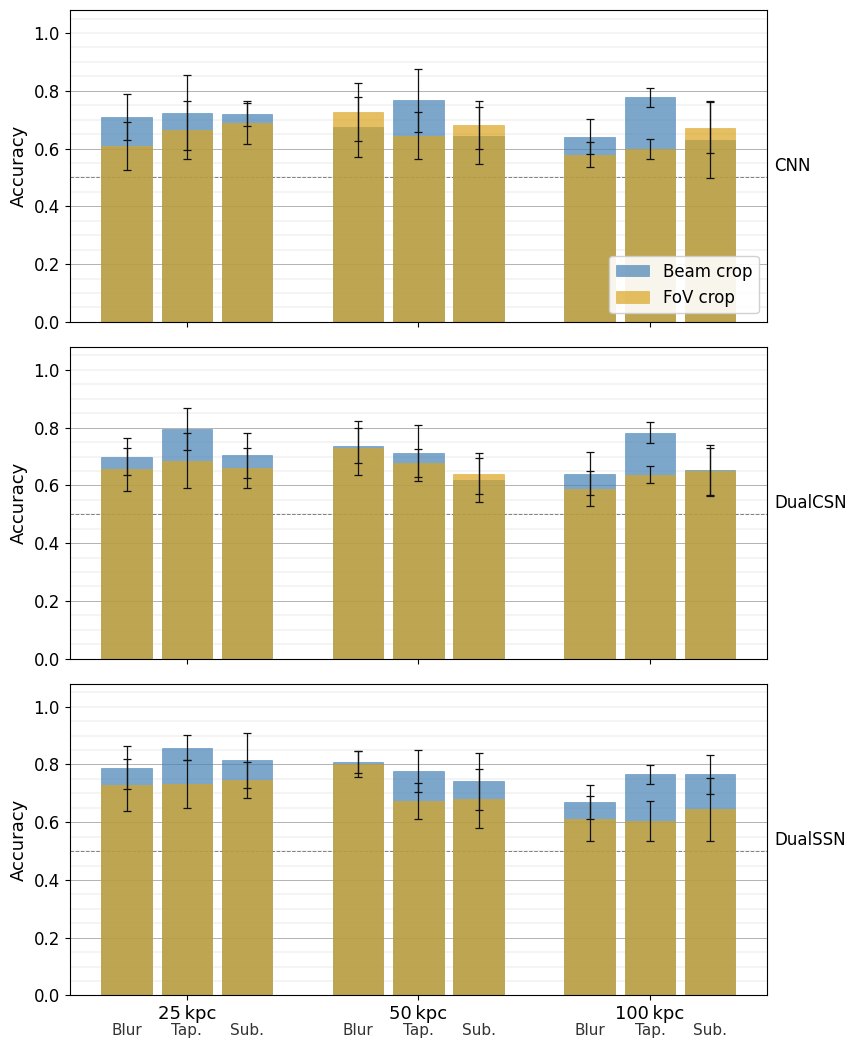

Saved: /users/mbredber/p2_DCRECLASS/outputs/scratch/figures/classifying/explore_classification_results_outputs/accuracy_bars_version_blur_crop.pdf


In [16]:
# ── Edit the call below to your comparison of interest ───────────────────────
#
# DISTINGUISH_RESULT_VERSIONS : bool
#   True  → bar style reflects data tier:
#             latest (metrics_dir)     = solid
#             legacy (LegacyRunConfig) = hatched  ///
#             old    (old_metrics_dir) = hollow
#
# RESULT_VERSION_PRIORITY : list | 'highest'
#   Per bar, the first tier that has data wins.  Unlisted tiers are skipped.
#     ['latest', 'legacy', 'old']  → latest preferred; legacy fills missing bars
#     ['legacy', 'latest', 'old']  → legacy preferred where available
#     ['latest']                   → only show bars with latest data
#     'highest'                    → show whichever tier has the highest mean
#                                    accuracy for that bar (bar style still
#                                    reflects which tier was selected)
#
# classifiers entries:
#   (label, primary_cfg)                    – single config
#   (label, primary_cfg, fallback_cfg)      – primary tried first;
#                                             fallback (LegacyRunConfig) fills
#                                             in any bar where primary has no data
#
DISTINGUISH_RESULT_VERSIONS  = False
RESULT_VERSION_PRIORITY      = ['latest']
SHOW_RADIOUNET               = False
SHOW_N_FILES                 = False

fig = plot_accuracy_bars(
    base_cfg = None,
    scales   = [25, 50, 100],
    scale_version    = ['circular', 'tapering', 'sub'],
    overlay_vary     = 'crop_mode',
    overlay_values   = ['beam_crop', 'fov_crop'],
    metric           = 'accuracy',
    distinguish_result_versions = DISTINGUISH_RESULT_VERSIONS,
    result_version_priority     = RESULT_VERSION_PRIORITY,
    show_radiounet_ref          = SHOW_RADIOUNET,
    show_n_files                = SHOW_N_FILES,
    classifiers = [
        ('CNN',
            RunConfig(classifier='ImageCNN', folds=list(range(10)), num_experiments=3)),
        ('DualCSN',
            RunConfig(classifier='DualCSN', folds=list(range(10)), num_experiments=3),
            {'beam_crop':  LegacyRunConfig(classifier='DualCSN', section='beam_cropping',
                                           folds=list(range(10)), num_experiments=3),
             'pixel_crop': LegacyRunConfig(classifier='DualCSN', section='pixel_cropping',
                                           folds=list(range(10)), num_experiments=3)}),
        ('DualSSN',
            RunConfig(classifier='DualSSN', folds=list(range(10)), num_experiments=3),
            {'beam_crop':  LegacyRunConfig(classifier='DualSSN', section='beam_cropping',
                                           folds=list(range(10)), num_experiments=3),
             'pixel_crop': LegacyRunConfig(classifier='DualSSN', section='pixel_cropping',
                                           folds=list(range(10)), num_experiments=3)}),
    ],
)

_fname = os.path.join(OUTPUT_DIR, 'accuracy_bars_version_blur_crop.pdf')
fig.savefig(_fname, bbox_inches='tight')
plt.show()
plt.close()
print('Saved:', _fname)

In [ ]:
# ── Reference (RAW) accuracy: classifiers on x-axis, crop mode as colour ─────
# Layout: [CNN: fov|pixel|beam] [DualCSN: fov|pixel|beam] [DualSSN: fov|pixel|beam] [RadioUnet]
#
RESULT_VERSION_PRIORITY     = ['latest']
DISTINGUISH_RESULT_VERSIONS = False
RADIOUNET_VALUE             = 0.73
SHOW_N_FILES                = True

_ref_crops      = ['pixel_crop', 'fov_crop', 'beam_crop']
_ref_crop_lbls  = ['Pixel crop', 'FoV crop', 'Beam crop']
_ref_colours    = ['tomato', 'goldenrod', 'steelblue']

_ref_clfs = [
    ('CNN',
     RunConfig(classifier='ImageCNN', folds=list(range(10)), num_experiments=3),
     {'beam_crop': LegacyRunConfig(classifier='CNN', section='beam_cropping')}),
    ('DualCSN',
     RunConfig(classifier='DualCSN', folds=list(range(10)), num_experiments=3),
     {'beam_crop': LegacyRunConfig(classifier='DualCSN', section='beam_cropping')}),
    ('DualSSN',
     RunConfig(classifier='DualSSN', folds=list(range(10)), num_experiments=3),
     {'beam_crop': LegacyRunConfig(classifier='DualSSN', section='beam_cropping')}),
]

# Geometry: 3 crop-mode sub-bars per classifier, 1 bar for RadioUnet
_n_sub   = len(_ref_crops)
_group_w = 0.80
_sub_w   = _group_w / _n_sub
_bar_w   = _sub_w * 0.84
_x_pos   = np.arange(len(_ref_clfs) + 1, dtype=float)   # +1 for RadioUnet
_x_lbls  = [label for label, *_ in _ref_clfs] + ['RadioUnet']

import matplotlib.colors as _mcolors

fig_ref, ax_ref = plt.subplots(figsize=(7, 4))

for xi, (label, cfg, fallbacks) in enumerate(_ref_clfs):
    for ci, crop in enumerate(_ref_crops):
        _colour = _ref_colours[ci]
        _off    = _sub_w * (ci - (_n_sub - 1) / 2)
        _cfg_v  = dataclasses.replace(cfg, version='RAW', crop_mode=crop)
        _vbt, _, _ = _load_vals_from_cfg(_cfg_v, 'accuracy')

        if fallbacks and crop in fallbacks:
            _fb_vbt, _, _ = _load_vals_from_cfg(
                dataclasses.replace(fallbacks[crop], version='RAW'), 'accuracy')
            _vbt['legacy'].extend(_fb_vbt['legacy'])

        _avail = [t for t in ('latest', 'old', 'legacy') if _vbt[t]]
        _tier  = next((t for t in RESULT_VERSION_PRIORITY if t in _avail), None)
        if _tier is None:
            continue
        _arr        = np.array(_vbt[_tier])
        _mean, _std = _arr.mean(), _arr.std()
        _hatch      = '///' if (DISTINGUISH_RESULT_VERSIONS and _tier == 'legacy') else None
        ax_ref.bar(
            _x_pos[xi] + _off, _mean, _bar_w,
            yerr=_std, capsize=3,
            color=_colour, alpha=0.80, hatch=_hatch,
            error_kw=dict(linewidth=0.9, ecolor='#111111', capthick=0.9),
            zorder=2,
            label=_ref_crop_lbls[ci] if xi == 0 else '_nolegend_',
        )
        if SHOW_N_FILES:
            _dark = tuple(c * 0.55 for c in _mcolors.to_rgba(_colour)[:3]) + (1.0,)
            _y_top = _mean + (0.0 if np.isnan(_std) else _std)
            ax_ref.text(_x_pos[xi] + _off, _y_top + 0.012, str(len(_arr)),
                        ha='center', va='bottom', fontsize=7.5,
                        color=_dark, fontweight='bold', clip_on=False)

# ── RadioUnet (single black bar, centred in its group) ────────────────────────
ax_ref.bar(_x_pos[-1], RADIOUNET_VALUE, _group_w * 0.84,
           color='black', alpha=0.80, zorder=2, label='RadioUnet')

# ── Formatting ────────────────────────────────────────────────────────────────
ax_ref.set_xticks(_x_pos)
ax_ref.set_xticklabels(_x_lbls, fontsize=13)
ax_ref.set_ylabel('Accuracy', fontsize=13)
ax_ref.tick_params(axis='y', labelsize=12)
ax_ref.set_ylim(0, 1.08)
for _y in np.arange(0.05, 1.08, 0.05):
    _major = _y in {0.2, 0.4, 0.6, 0.8}
    ax_ref.axhline(_y, color='grey',
                   linewidth=0.7 if _major else 0.3,
                   alpha=0.6 if _major else 0.4, zorder=0)
ax_ref.axhline(0.5, color='grey', linewidth=0.7, linestyle='--', zorder=1)
_h, _l = ax_ref.get_legend_handles_labels()
ax_ref.legend(_h, _l, fontsize=11, framealpha=0.9, loc='lower right')

fig_ref.tight_layout()
_fname = os.path.join(OUTPUT_DIR, 'reference_accuracy_crop_comparison.pdf')
fig_ref.savefig(_fname, bbox_inches='tight')
plt.show()
plt.close()
print('Saved:', _fname)

## 5. Legacy results (from LaTeX tables)

`LegacyRunConfig` reads pre-stored `[mean, std]` pairs from `legacy_metrics.json`
and feeds them into the same `plot_accuracy_bars` machinery as normal `RunConfig`s.
The two folds encode mean±std exactly: `std([µ−σ, µ+σ]) == σ` (ddof=0).

Legacy bars are **filled** (not hollow) to distinguish them from old pkl data.

── pkl load summary [CNN] ───────────────────────────────
  ✗ FAILED/MISSING:
      version=RAW, blur_method=circular  (0 missing)
      version=Blur25kpc, blur_method=circular  (0 missing)
      version=Blur50kpc, blur_method=circular  (0 missing)
      version=Blur100kpc, blur_method=circular  (0 missing)
      version=T25kpc  (0 missing)
      version=T50kpc  (0 missing)
      version=T100kpc  (0 missing)
      version=T25kpcSUB  (0 missing)
      version=T50kpcSUB  (0 missing)
      version=T100kpcSUB  (0 missing)
── pkl load summary [DualCSN] ───────────────────────────
  ✗ FAILED/MISSING:
      version=RAW, blur_method=circular  (0 missing)
      version=Blur25kpc, blur_method=circular  (0 missing)
      version=Blur50kpc, blur_method=circular  (0 missing)
      version=Blur100kpc, blur_method=circular  (0 missing)
      version=T25kpc  (0 missing)
      version=T50kpc  (0 missing)
      version=T100kpc  (0 missing)
      version=T25kpcSUB  (0 missing)
      version=T50kpcSUB  (0

/tmp/ipykernel_228845/3438513578.py:506: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 1, 0.96) if title else None)


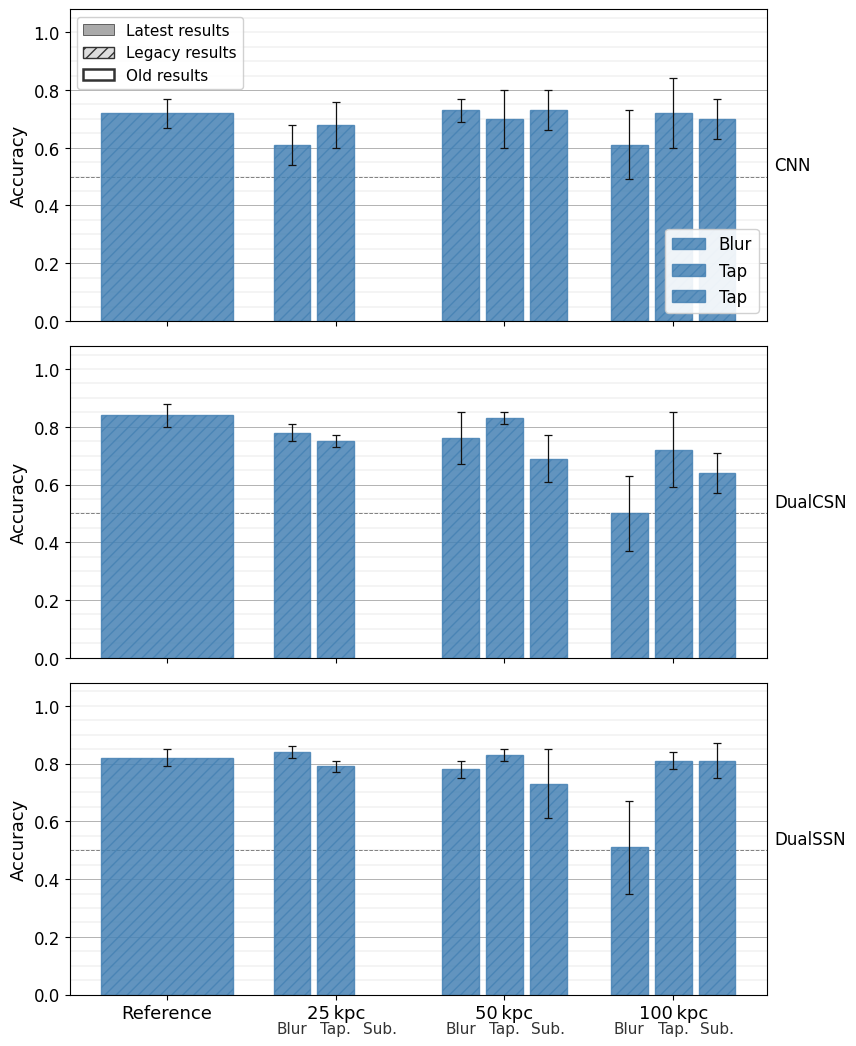

Saved: /users/mbredber/p2_DCRECLASS/outputs/scratch/figures/classifying/explore_classification_results_outputs/legacy_accuracy_bars_percentile.pdf


In [18]:
# ── Percentile results (CNN / DualCSN / DualSSN) ─────────────────────────────
fig_pct = plot_accuracy_bars(
    base_cfg       = None,
    scales         = [0, 25, 50, 100],
    scale_version  = ['circular', 'tapering', 'sub'],
    metric         = 'accuracy',
    classifiers    = [
        ('CNN',     LegacyRunConfig(classifier='CNN',     section='beam_cropping')),
        ('DualCSN', LegacyRunConfig(classifier='DualCSN', section='beam_cropping')),
        ('DualSSN', LegacyRunConfig(classifier='DualSSN', section='beam_cropping')),
    ],
    colours            = ['steelblue'],
)
_fname = os.path.join(OUTPUT_DIR, 'legacy_accuracy_bars_percentile.pdf')
fig_pct.savefig(_fname, bbox_inches='tight')
plt.show(); plt.close()
print('Saved:', _fname)


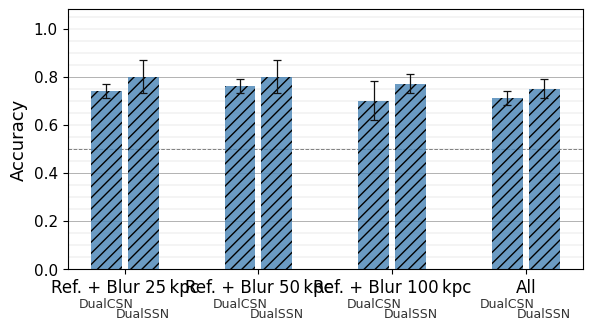

Saved: /users/mbredber/p2_DCRECLASS/outputs/scratch/figures/classifying/explore_classification_results_outputs/legacy_accuracy_bars_stacking.pdf


In [19]:
# ── Stacking results (DualCSN / DualSSN side by side) ───────────────────────
#
# DISTINGUISH_RESULT_VERSIONS : bool
#   True  → legacy bars hatched ///
#
# RESULT_VERSION_PRIORITY : list | 'highest'
#   Per bar, the first tier that has data wins.
#
DISTINGUISH_RESULT_VERSIONS = True
RESULT_VERSION_PRIORITY     = ['latest', 'legacy']

_stk_clfs    = ['DualCSN', 'DualSSN']
_stk_scales  = [25, 50, 100, 0]
_stk_xlabels = ['Ref. + Blur 25\u202fkpc', 'Ref. + Blur 50\u202fkpc', 'Ref. + Blur 100\u202fkpc', 'All']
_colour      = 'steelblue'

_n       = len(_stk_clfs)
_grp_w   = 0.55
_sub_w   = _grp_w / _n
_bar_w   = _sub_w * 0.84
_x_pos   = np.arange(len(_stk_scales), dtype=float)

fig_stk, ax_stk = plt.subplots(figsize=(6, 3.5))

for c_idx, clf in enumerate(_stk_clfs):
    _off  = _sub_w * (c_idx - (_n - 1) / 2)
    _cfg  = LegacyRunConfig(classifier=clf, section='stacking')
    for xi, scale in enumerate(_stk_scales):
        _ver      = 'RAW' if scale == 0 else f'Blur{scale}kpc'
        _cfg_v    = dataclasses.replace(_cfg, version=_ver)
        _vbt, _, _ = _load_vals_from_cfg(_cfg_v, 'accuracy')
        _avail    = [t for t in ('latest', 'old', 'legacy') if _vbt[t]]
        _tier     = next((t for t in RESULT_VERSION_PRIORITY if t in _avail), None)
        if _tier is None:
            continue
        _arr  = np.array(_vbt[_tier])
        _mean, _std = _arr.mean(), _arr.std()
        _hatch = '///' if (DISTINGUISH_RESULT_VERSIONS and _tier == 'legacy') else None
        ax_stk.bar(
            _x_pos[xi] + _off, _mean, _bar_w,
            yerr=_std, capsize=3,
            color=_colour, alpha=0.80, hatch=_hatch,
            error_kw=dict(linewidth=0.9, ecolor='#111111', capthick=0.9),
            zorder=2,
        )

# ── Classifier sub-labels under each bar ─────────────────────────────────────
ax_stk.set_xticks(_x_pos)
ax_stk.set_xticklabels(_stk_xlabels, fontsize=12)
ax_stk.set_ylabel('Accuracy', fontsize=13)
ax_stk.tick_params(axis='y', labelsize=11)
ax_stk.set_ylim(0, 1.08)

_y_lo, _y_hi = ax_stk.get_ylim()
_y_sub = _y_lo - 0.11 * (_y_hi - _y_lo)
_y_sub_extra = {'DualSSN': 0.04}
for c_idx, clf in enumerate(_stk_clfs):
    _off = _sub_w * (c_idx - (_n - 1) / 2)
    _y = _y_sub - _y_sub_extra.get(clf, 0.0)
    for xi in range(len(_stk_scales)):
        ax_stk.text(_x_pos[xi] + _off, _y, clf,
                    ha='center', va='top', fontsize=9,
                    color='#333333', clip_on=False)

# ── Grid ──────────────────────────────────────────────────────────────────────
for _y in np.arange(0.05, 1.08, 0.05):
    _major = _y in {0.2, 0.4, 0.6, 0.8}
    ax_stk.axhline(_y, color='grey',
                   linewidth=0.7 if _major else 0.3,
                   alpha=0.6 if _major else 0.4, zorder=0)
ax_stk.axhline(0.5, color='grey', linewidth=0.7, linestyle='--', zorder=1)

fig_stk.tight_layout()
fig_stk.subplots_adjust(bottom=0.22)

_fname = os.path.join(OUTPUT_DIR, 'legacy_accuracy_bars_stacking.pdf')
fig_stk.savefig(_fname, bbox_inches='tight')
plt.show()
plt.close()
print('Saved:', _fname)

## 6. Confusion matrices — beam_crop comparison

Average confusion matrices (mean ± std across folds & experiments) for the three classifiers on RAW data with `beam_crop`.

Loaded 30 pkl files, failed/missing 0.


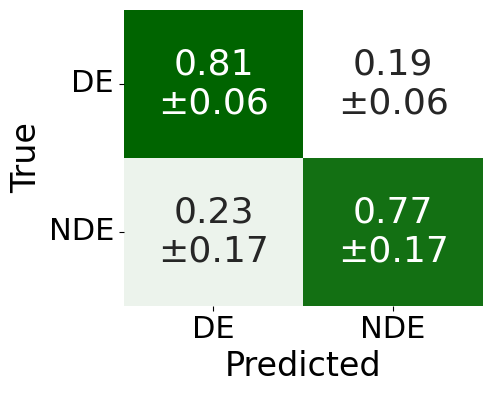

n=30  Acc: 0.79 ± 0.08
Saved: /users/mbredber/p2_DCRECLASS/outputs/scratch/figures/classifying/explore_classification_results_outputs/confusion_matrices/cm_DualSSN_beam_crop_Blur25kpc.pdf


In [20]:
import seaborn as _sns
from sklearn.metrics import confusion_matrix as _confusion_matrix
from matplotlib.colors import LinearSegmentedColormap as _LSC
from dcreclass.data import get_classes as _get_classes

# ── Configuration ─────────────────────────────────────────────────────────────
CM_CLASSIFIER = 'DualSSN'    # 'ImageCNN' | 'DualCSN' | 'DualSSN'
CM_CROP_MODE  = 'beam_crop'  # 'beam_crop' | 'fov_crop'
CM_VERSION    = 'Blur25kpc'     # 'RAW' | 'T25kpc' | 'T50kpc' | 'T100kpc'
                             # 'Blur25kpc' | 'Blur50kpc' | 'Blur100kpc'
# ─────────────────────────────────────────────────────────────────────────────

_cm_save_dir = os.path.join(OUTPUT_DIR, 'confusion_matrices')
os.makedirs(_cm_save_dir, exist_ok=True)

_cmap = _LSC.from_list('wg', ['white', '#006400'])
_desc = {cls['tag']: cls['description'] for cls in _get_classes()}

cm_cfg     = RunConfig(classifier=CM_CLASSIFIER, crop_mode=CM_CROP_MODE,
                       version=CM_VERSION,
                       folds=list(range(10)), num_experiments=3)
cm_metrics = load_run(cm_cfg)

_largest_sz = max(sz for sizes in cm_cfg.dataset_sizes.values() for sz in sizes)
cms, acc_vals = [], []
for fold in cm_cfg.folds:
    subset = max(cm_cfg.dataset_sizes[fold])
    if subset != _largest_sz:
        continue
    for exp in range(cm_cfg.num_experiments):
        k = f'{subset}_{fold}_{exp}_{cm_cfg.lr}_{cm_cfg.reg}'
        acc_vals.extend(cm_metrics.get(f'accuracy_{k}', []))
        true_list = cm_metrics.get(f'all_true_labels_{k}', [])
        pred_list = cm_metrics.get(f'all_pred_labels_{k}', [])
        if not true_list or not pred_list:
            continue
        base   = cm_cfg.base_key(fold, subset)
        y_true = true_list[0].get(base, [])
        y_pred = pred_list[0].get(base, [])
        if len(y_true) == 0:
            continue
        cm = _confusion_matrix(y_true, y_pred, normalize='true',
                               labels=list(range(len(cm_cfg.galaxy_classes))))
        if cm.shape[0] == len(cm_cfg.galaxy_classes):
            cms.append(cm)

if not cms:
    print('No data found — check classifier/crop_mode/version.')
else:
    cms_arr  = np.array(cms)
    avg_cm   = cms_arr.mean(axis=0)
    std_cm   = cms_arr.std(axis=0)
    acc_arr  = np.array([v for v in acc_vals if np.isfinite(v)])
    acc_mean = acc_arr.mean() if acc_arr.size else float('nan')
    acc_std  = acc_arr.std()  if acc_arr.size else float('nan')

    class_labels = [_desc.get(tag, str(tag)) for tag in cm_cfg.galaxy_classes]
    ann = np.empty(avg_cm.shape, dtype=object)
    for i in range(avg_cm.shape[0]):
        for j in range(avg_cm.shape[1]):
            ann[i, j] = f'{avg_cm[i,j]:.2f}\n±{std_cm[i,j]:.2f}'

    fig_cm, ax_cm = plt.subplots(figsize=(5, 4))
    _sns.heatmap(avg_cm, annot=ann, fmt='', cmap=_cmap,
                 xticklabels=class_labels, yticklabels=class_labels,
                 annot_kws={'fontsize': 26}, cbar=False, ax=ax_cm)
    ax_cm.set_xticklabels(ax_cm.get_xticklabels(), fontsize=22, rotation=0)
    ax_cm.set_yticklabels(ax_cm.get_yticklabels(), fontsize=22, rotation=0)
    ax_cm.set_xlabel('Predicted', fontsize=24)
    ax_cm.set_ylabel('True', fontsize=24)
    fig_cm.tight_layout()

    _save_path = os.path.join(_cm_save_dir, f'cm_{CM_CLASSIFIER}_{CM_CROP_MODE}_{CM_VERSION}.pdf')
    fig_cm.savefig(_save_path, bbox_inches='tight')
    plt.show()
    plt.close(fig_cm)
    print(f'n={cms_arr.shape[0]}  Acc: {acc_mean:.2f} ± {acc_std:.2f}')
    print(f'Saved: {_save_path}')